# Gadget4 vs StePS-PDS — head-to-head, and grid-load vs glass-load

A flat **Gadget4** run vs the curved **Poincaré-dodecahedral (S³/I\*)** StePS runs, from the
same realization and the same flat FLRW background, plus an A/B test of the PDS **particle
load**.

- **Gadget128 (flat)** — `gadget128_flat`, the flat T³ gold standard.
- **PDS grid-IC** — `test256disc`: 256³, discrete S³/I\* spectrum (n=12,20), rectangular
  stereographic **grid** load clipped to the dodecahedral domain.
- **PDS glass-IC** — `test256glass`: identical to the above **except** the unperturbed load
  is a reverse-gravity **glass** (relaxed from a Poisson load in an EdS background). This is
  the only difference, so it isolates what the load does.

Contents: **(1)** matched density slices at z=0, **(2)** density evolution, **(3)** power-
spectrum evolution, **(4)** P(k) ratios & growth, **(5)** grid-vs-glass high-k lattice imprint.

> **Frames.** For the Gadget comparison the PDS is kept in **stereographic** coordinates (the
> frame in which it shares Gadget's flat realization) with Gadget shifted by L/2 onto the same
> origin; the **geodesic-normal** map (≈ physical comoving, Ω≈2 stretch) is used only for the
> physical density slices. For P(k) the PDS **static low-k pedestal is subtracted** (first
> snapshot) — note this pedestal is *geometric* (curved-domain counts-in-cells + discrete
> modes) and is the **same for the grid and glass loads**, so the subtraction is still needed
> for both; the glass's benefit shows up at **high k** (§5), not here. Background is flat in
> all runs (Ω_m+Ω_Λ=1), so a(t) is identical.

In [1]:
import numpy as np, h5py, os
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter
from scipy.integrate import quad

# cosmology (shared, flat)
OM, OL, HUB = 0.3106, 0.6894, 0.67702
R_CURV  = 3100.0           # PDS curvature radius [Mpc]
A_START = 1.0/32.0         # z = 31

# runs. The two PDS runs are identical (256^3, discrete S^3/I* spectrum n=12,20, LCDM)
# EXCEPT the unperturbed particle load: a rectangular stereographic GRID (test256disc) vs a
# reverse-gravity GLASS (test256glass). Gadget128 is the flat T^3 reference.
RUNS = {
    'Gadget128 (flat)':  dict(dir='/scratch/csabai/gadget128_flat', kind='gadget', w=3),
    'PDS grid-IC':       dict(dir='/scratch/csabai/test256disc',    kind='pds',    w=4),
    'PDS glass-IC':      dict(dir='/scratch/csabai/test256glass',   kind='pds',    w=4),
}
ZLIST  = [30,15,10,5,3,2,1,0.7,0.5,0.2,0]   # all output lists are identical
IDX_OF = {z:i for i,z in enumerate(ZLIST)}

def Dgrow(a):
    I,_ = quad(lambda ap: 1.0/(ap*np.sqrt(OM/ap**3+OL))**3, 1e-8, a)
    return 2.5*OM*np.sqrt(OM/a**3+OL)*I
print('linear growth D(0)/D(31) =', round(Dgrow(1.0)/Dgrow(A_START), 2))

linear growth D(0)/D(31) = 25.13


In [2]:
def load_phys(run, idx):
    # load snapshot -> (positions in physical comoving Mpc, redshift)
    f = os.path.join(run['dir'], 'snapshot_%0*d.hdf5' % (run['w'], idx))
    with h5py.File(f, 'r') as h:
        x = h['PartType1/Coordinates'][:].astype(np.float64)
        z = float(h['Header'].attrs['Redshift'])
    if run['kind'] == 'gadget':
        x = x / HUB                                   # Mpc/h -> Mpc
    else:                                             # PDS: stereographic -> geodesic-normal
        r = np.sqrt((x**2).sum(1)); r = np.where(r < 1e-9, 1e-9, r)
        chi = 2.0*np.arctan2(r, R_CURV)               # geodesic angle from centre
        x = (R_CURV*chi/r)[:, None]*x                 # physical comoving distance along geodesic
    return x, z

# Matched-frame loader for head-to-head comparison with Gadget. The PDS shares Gadget's
# flat realization in STEREOGRAPHIC coords (the geodesic map stretches structures by Omega~2
# and pulls them out of register). Gadget is shifted by L/2 onto the same origin.
def load_for_gadget_match(run, idx):
    L = 1200.0
    f = os.path.join(run['dir'], 'snapshot_%0*d.hdf5' % (run['w'], idx))
    with h5py.File(f, 'r') as h:
        x = h['PartType1/Coordinates'][:].astype(np.float64)
        z = float(h['Header'].attrs['Redshift'])
    if run['kind'] == 'gadget':
        x = x / HUB                          # Mpc/h -> Mpc (box frame)
        x = np.mod(x + L/2, L) - L/2         # shift by L/2, wrap -> centre on box origin
    # PDS: keep STEREOGRAPHIC coords (already centred on origin) — do NOT map to geodesic
    return x, z


def density_slice(x, half=300.0, slab=20.0, ng=300, smooth=1.2):
    # smoothed projected density in a thin central slab
    x = x - np.median(x, 0)
    m = (np.abs(x[:,2])<slab) & (np.abs(x[:,0])<half) & (np.abs(x[:,1])<half)
    H2,_,_ = np.histogram2d(x[m,0], x[m,1], bins=ng, range=[[-half,half]]*2)
    return gaussian_filter(H2.T, smooth)

def power_spectrum(x, half=400.0, ng=64):
    # shot-noise-subtracted P(k) in a central physical cube -> k[1/Mpc], P[Mpc^3]
    x = x - np.median(x, 0)
    m = (np.abs(x)<half).all(1); xx = x[m]+half; L = 2*half; N = len(xx)
    idx = np.clip((xx/L*ng).astype(int), 0, ng-1)
    g = np.zeros((ng,)*3); np.add.at(g, (idx[:,0],idx[:,1],idx[:,2]), 1.0)
    d = g/g.mean()-1.0; fk = np.fft.fftn(d); Pk = np.abs(fk)**2 * L**3/ng**6
    kf = 2*np.pi/L
    kk = np.sqrt(sum(np.meshgrid(*[np.fft.fftfreq(ng,1/ng)**2]*3, indexing='ij')))*kf
    shot = L**3/N
    ks, Ps = [], []
    for q in range(1, ng//2):
        sel = (kk>=(q-0.5)*kf) & (kk<(q+0.5)*kf)
        if sel.sum()>0: ks.append(q*kf); Ps.append(Pk[sel].mean()-shot)
    return np.array(ks), np.array(Ps)

# --- Curved-load pedestal handling (makes the PDS P(k) comparable to flat Gadget) ---
# The stereographic grid clipped to the dodecahedral domain injects a large, *static*
# (non-growing) low-k counts-in-cells power. It dwarfs the linear signal at high z and is
# ~comparable to it at z=0, inflating the raw PDS low-k P(k) ~4x over Gadget. We remove it
# by subtracting the earliest-snapshot (z~30) P(k) as a fixed load template. (Diagnostic:
# the raw PDS/Gadget low-k ratio runs 137x at the IC -> 1.9x at z=0 -- the opposite of an
# over-clustering, i.e. a static load artifact, not gravity.)
def pds_pedestal(run):
    return power_spectrum(load_for_gadget_match(run, 0)[0])   # idx 0 = z~30, ~pure load

def clustering_pk(run, idx, ped=None):
    # P(k) with the PDS curved-load pedestal removed (Gadget: pass ped=None)
    x, _ = (load_for_gadget_match if run['kind'] == 'pds' else load_phys)(run, idx)
    k, P = power_spectrum(x)
    if ped is not None:
        P = P - ped[1]
    return k, P

## 1. Density slices at z = 0
Same physical region (central 600 Mpc, 40 Mpc slab), same colour scale.

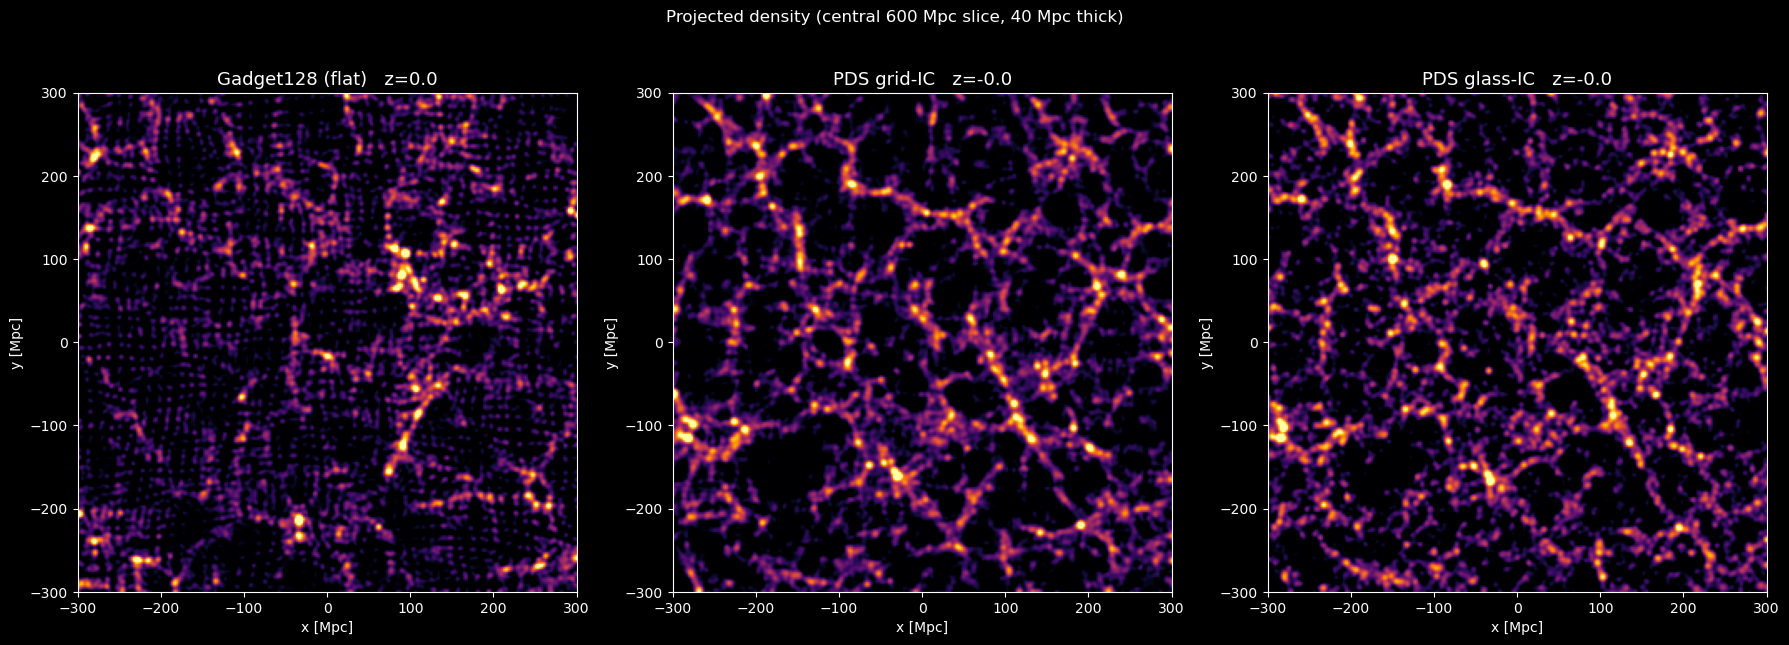

In [3]:
plt.style.use('dark_background')
fig, axes = plt.subplots(1, len(RUNS), figsize=(6*len(RUNS), 6.2))
for ax, (name, run) in zip(axes, RUNS.items()):
    if run['kind'] == 'pds':
        x, z = load_for_gadget_match(run, IDX_OF[0])
    else:
        x, z = load_phys(run, IDX_OF[0])
    d = np.log10(density_slice(x)+0.5)
    # per-panel scaling so the web is clearly visible despite the 128 vs 256 resolution difference
    ax.imshow(d, origin='lower', extent=[-300,300,-300,300], cmap='inferno',
              vmin=np.percentile(d,40), vmax=np.percentile(d,99.7))
    ax.set_title('%s   z=%.1f' % (name, z), fontsize=13)
    ax.set_xlabel('x [Mpc]'); ax.set_ylabel('y [Mpc]')
fig.suptitle('Projected density (central 600 Mpc slice, 40 Mpc thick)', y=1.02)
plt.tight_layout(); plt.show()

## 2. Density evolution (PDS discrete-IC)
The cosmic web assembling from z=5 to z=0.

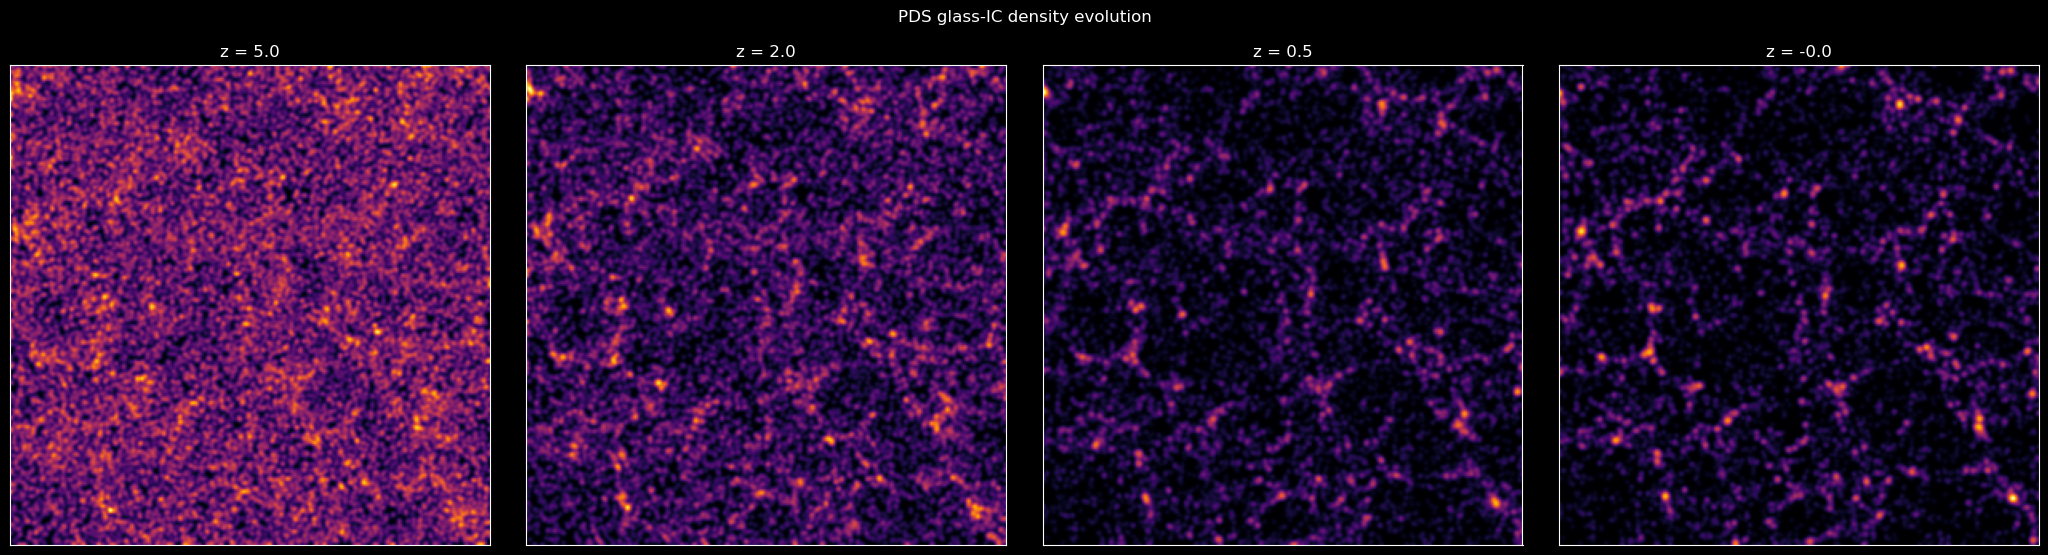

In [4]:
run = RUNS['PDS glass-IC']  # or 'PDS grid-IC'
zs = [5, 2, 0.5, 0]
fig, axes = plt.subplots(1, len(zs), figsize=(5.2*len(zs), 5.4))
for ax, zz in zip(axes, zs):
    x, z = load_phys(run, IDX_OF[zz]); d = density_slice(x)
    ax.imshow(np.log10(d+0.5), origin='lower', extent=[-300,300,-300,300], cmap='inferno')
    ax.set_title('z = %.1f' % z); ax.set_xticks([]); ax.set_yticks([])
fig.suptitle('PDS glass-IC density evolution', y=1.02)
plt.tight_layout(); plt.show()

## 3. Power-spectrum evolution
P(k) in a central physical cube (shot-noise subtracted), at z = 10, 5, 2, 0.

For the PDS runs the **static curved-load pedestal is removed** (the stereographic grid
clipped to the dodecahedral domain injects a large, *non-growing* low-k counts-in-cells
power — see the caveats below). The dashed line is a smooth **analytic linear reference**
(Eisenstein-Hu no-wiggle), anchored to Gadget's quasi-linear z=0 large scales — the same
theory curve in every panel, since the flat background is identical for all runs. The z=0
curves should hug it on large scales and rise above it on small scales (nonlinear growth).

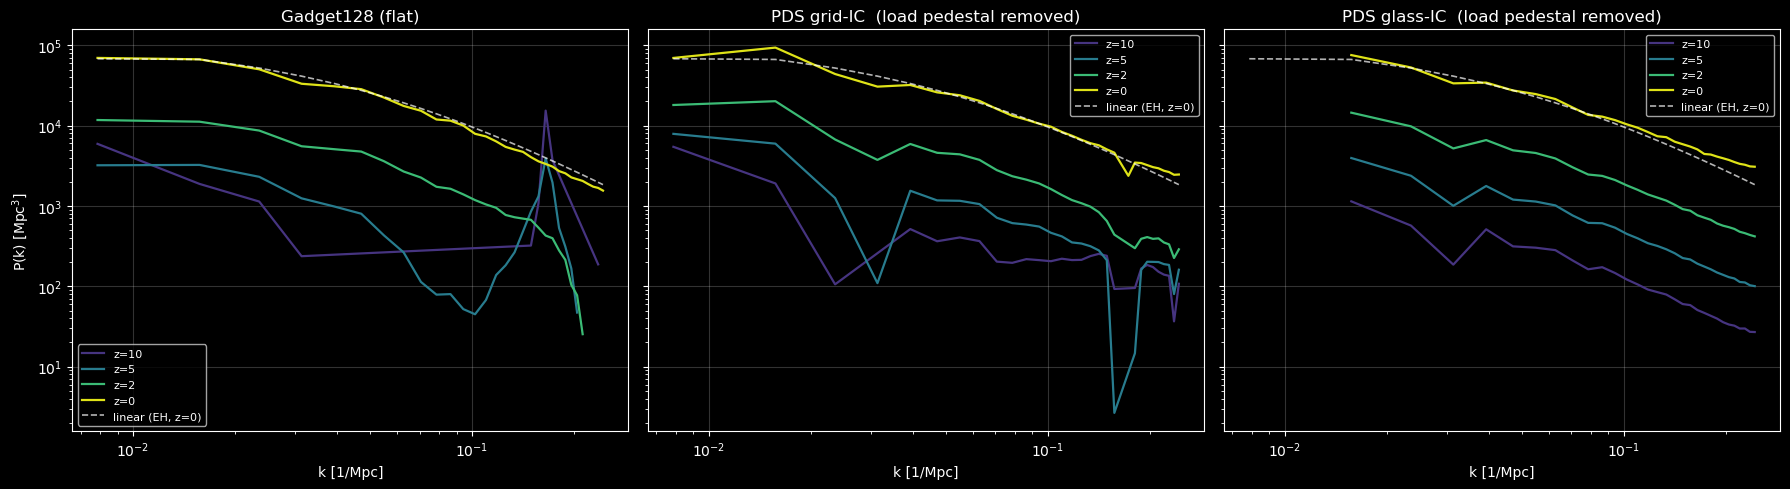

In [5]:
def Pk_lin_EH(k, Om0=OM, Ob0=0.0486, h=HUB, ns=0.9665, Tcmb=2.7255):
    # Eisenstein-Hu 1998 no-wiggle linear P(k) shape (arbitrary norm); k in 1/Mpc
    theta = Tcmb/2.7; omh2 = Om0*h*h; obh2 = Ob0*h*h
    s = 44.5*np.log(9.83/omh2)/np.sqrt(1+10*obh2**0.75)
    a = 1 - 0.328*np.log(431*omh2)*(Ob0/Om0) + 0.38*np.log(22.3*omh2)*(Ob0/Om0)**2
    Geff = Om0*h*(a + (1-a)/(1+(0.43*k*s)**4))
    q = (k/h)*theta**2/Geff
    C0 = 14.2 + 731.0/(1+62.5*q); L0 = np.log(2*np.e + 1.8*q)
    T = L0/(L0 + C0*q*q)
    return k**ns * T**2

z_show = [10, 5, 2, 0]
colors = plt.cm.viridis(np.linspace(0.15, 0.95, len(z_show)))
fig, axes = plt.subplots(1, len(RUNS), figsize=(6*len(RUNS), 5), sharex=True, sharey=True)
pk_cache = {}

# static curved-load pedestal template for each PDS run (Gadget: none)
peds = {name: (pds_pedestal(run) if run['kind'] == 'pds' else None) for name, run in RUNS.items()}

# smooth analytic linear reference (Eisenstein-Hu), anchored to Gadget's quasi-linear z=0
# large scales -- same theory curve in every panel (identical flat background for all runs).
gname    = next(n for n, r in RUNS.items() if r['kind'] == 'gadget')
kg0, Pg0 = clustering_pk(RUNS[gname], IDX_OF[0])
Plin     = Pk_lin_EH(kg0)
anc      = kg0 < 0.03
Plin    *= np.nanmean(Pg0[anc]) / np.nanmean(Plin[anc])

for ax, (name, run) in zip(axes, RUNS.items()):
    for z, c in zip(z_show, colors):
        k, P = clustering_pk(run, IDX_OF[z], ped=peds[name])
        pk_cache[(name, z)] = (k, P)
        ok = P > 0; ax.loglog(k[ok], P[ok], color=c, lw=1.6, label='z=%g' % z)
    ax.loglog(kg0, Plin, 'w--', lw=1.2, alpha=0.7, label='linear (EH, z=0)')
    tag = '  (load pedestal removed)' if run['kind'] == 'pds' else ''
    ax.set_title(name + tag); ax.set_xlabel('k [1/Mpc]'); ax.grid(alpha=0.2); ax.legend(fontsize=8)
axes[0].set_ylabel('P(k) [Mpc$^3$]')
plt.tight_layout(); plt.show()

## 4. P(k) ratios and growth
Left: PDS / Gadget P(k) ratio at z=0 (≈1 on well-sampled scales = the PDS reproduces Gadget).
Right: growth of the large-scale P(k) amplitude vs linear D(a)².

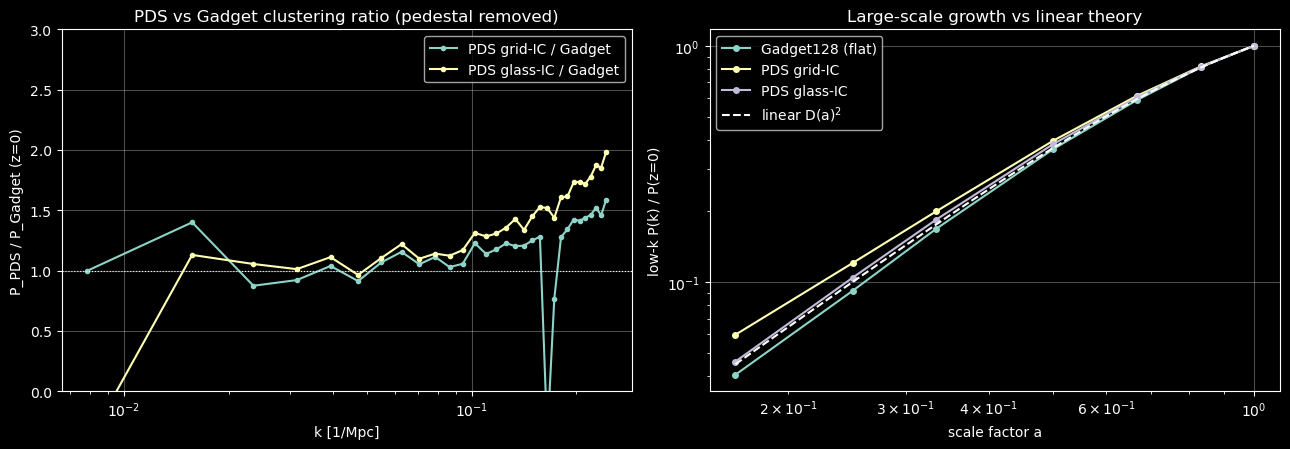

In [6]:
fig, (axr, axg) = plt.subplots(1, 2, figsize=(13, 4.6))
gname     = next(n for n, r in RUNS.items() if r['kind'] == 'gadget')
pds_names = [n for n, r in RUNS.items() if r['kind'] == 'pds']

# left: PDS/Gadget clustering ratio at z=0 (pedestal already removed in pk_cache)
kg, Pg = pk_cache[(gname, 0)]
for name in pds_names:
    kp, Pp = pk_cache[(name, 0)]
    n = min(len(Pg), len(Pp))
    r = Pp[:n]/np.where(Pg[:n] > 0, Pg[:n], np.nan)
    axr.semilogx(kg[:n], r, marker='o', ms=3, label=name + ' / Gadget')
axr.axhline(1, color='w', lw=0.8, ls=':'); axr.set_ylim(0, 3)
axr.set_xlabel('k [1/Mpc]'); axr.set_ylabel('P_PDS / P_Gadget (z=0)')
axr.legend(); axr.grid(alpha=0.3); axr.set_title('PDS vs Gadget clustering ratio (pedestal removed)')

# right: large-scale growth vs linear D(a)^2 (start at z=5; subtracted z=10 is ~pure noise)
zs = [5, 3, 2, 1, 0.5, 0.2, 0]
for name, run in RUNS.items():
    amp = []
    for z in zs:
        if (name, z) in pk_cache: k, P = pk_cache[(name, z)]
        else: k, P = clustering_pk(run, IDX_OF[z], ped=peds.get(name))
        nlow = max(1, len(P)//4); amp.append(np.nanmean(np.where(P[:nlow] > 0, P[:nlow], np.nan)))
    amp = np.array(amp); a = np.array([1/(1+z) for z in zs])
    axg.loglog(a, amp/amp[-1], marker='o', ms=4, label=name)
aa = np.linspace(1/6.0, 1, 50)
axg.loglog(aa, (np.array([Dgrow(x) for x in aa])/Dgrow(1.0))**2, 'w--', label='linear D(a)$^2$')
axg.set_xlabel('scale factor a'); axg.set_ylabel('low-k P(k) / P(z=0)')
axg.legend(); axg.grid(alpha=0.3); axg.set_title('Large-scale growth vs linear theory')
plt.tight_layout(); plt.show()

## 5. Grid load vs glass load — the high-k lattice imprint

The §3 pedestal lives at **low k** and is *geometric* (the curved dodecahedral-domain
counts-in-cells envelope + the discrete modes): it is **the same for the grid and the
glass load**, so the first-snapshot subtraction is still required for both. Where the
**glass actually wins is at high k**: a rectangular grid load imprints sharp **Bragg peaks**
at the lattice frequency. They dominate the early-time field and only wash out once
nonlinear evolution takes over. We track the peak high-k power (P/shot, k≈0.3–0.6 /Mpc;
the grid lattice is near the Nyquist of the 256³ load) versus redshift.

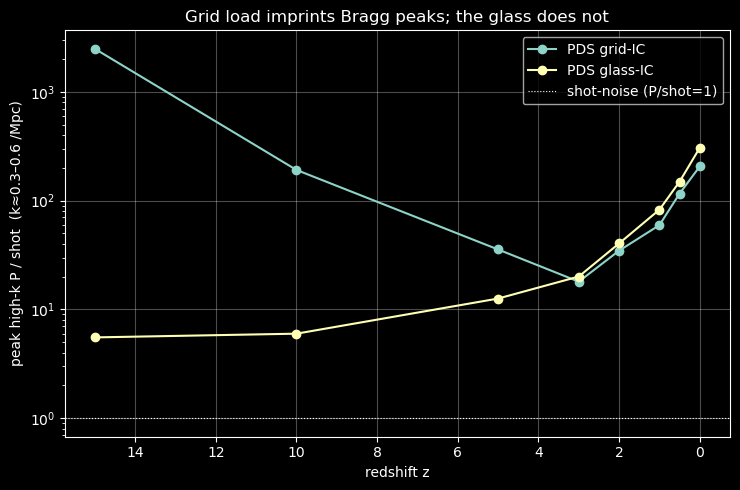

peak high-k P/shot:


  PDS grid-IC      z=15:  2483.6   z=10:  191.3   z=0:  206.0


  PDS glass-IC     z=15:     5.5   z=10:    6.0   z=0:  305.8


In [7]:
def hik_bragg(x, half=350.0, ng=128, klo=0.30, khi=0.60):
    # peak high-k power / shot in a band near the 256^3 load lattice frequency
    x = x - np.median(x, 0)
    m = (np.abs(x) < half).all(1); xx = x[m] + half; L = 2*half; N = len(xx)
    idx = np.clip((xx/L*ng).astype(int), 0, ng-1)
    g = np.zeros((ng,)*3); np.add.at(g, (idx[:,0], idx[:,1], idx[:,2]), 1.0)
    d = g/g.mean() - 1.0; P = np.abs(np.fft.fftn(d))**2 * L**3/ng**6
    kf = 2*np.pi/L
    kk = np.sqrt(sum(np.meshgrid(*[np.fft.fftfreq(ng,1/ng)**2]*3, indexing='ij')))*kf
    shot = L**3/N; band = (kk >= klo) & (kk < khi)
    return P[band].max()/shot

pds_names = [n for n, r in RUNS.items() if r['kind'] == 'pds']
z_track   = [15, 10, 5, 3, 2, 1, 0.5, 0]
fig, ax = plt.subplots(figsize=(7.5, 5))
for name in pds_names:
    run = RUNS[name]
    br = [hik_bragg(load_for_gadget_match(run, IDX_OF[z])[0]) for z in z_track]
    ax.semilogy(z_track, br, marker='o', label=name)
ax.axhline(1.0, color='w', ls=':', lw=0.8, label='shot-noise (P/shot=1)')
ax.invert_xaxis()
ax.set_xlabel('redshift z'); ax.set_ylabel('peak high-k P / shot  (k≈0.3–0.6 /Mpc)')
ax.set_title('Grid load imprints Bragg peaks; the glass does not')
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

print('peak high-k P/shot:')
for name in pds_names:
    run = RUNS[name]
    vals = {z: hik_bragg(load_for_gadget_match(run, IDX_OF[z])[0]) for z in (15, 10, 0)}
    print(f"  {name:<16} z=15:{vals[15]:8.1f}   z=10:{vals[10]:7.1f}   z=0:{vals[0]:7.1f}")

### Caveats / interpretation
- **Low-k pedestal is geometric, NOT a grid artifact.** A counts-in-cells P(k) of the PDS
  load carries a large *static* low-k power from the curved dodecahedral-domain envelope (plus
  the discrete S³/I\* modes). It is **identical for the grid and glass loads** (z≈30 low-k:
  grid 2.66e4 vs glass 2.72e4, both ≈140× Gadget) and non-growing, so the first-snapshot
  subtraction is **still required for both**. After subtraction the residual PDS/Gadget low-k
  ratio is ~1.3–1.5× — the documented residual of the v2.2.3.0 conformal *stopgap* integrator.
- **The dip near k≈0.03–0.05 /Mpc is a subtraction artifact, not a PDS feature.** The *raw*
  PDS P(k) is smooth there; the dip only appears after the pedestal subtraction. The static
  pedestal collapses ~200× between k≈0.016 and 0.055 (its envelope falloff knee sits at
  k≈0.03–0.05), so subtracting it slightly over-corrects right at that knee and carves a local
  deficit. The scale is set by how the smooth Ω³/domain envelope projects into the measurement
  cube — **not** by the ~1000 Mpc domain (its modes are at k~0.004–0.007) nor by small-scale
  physics. The grid dips deeper than the glass because its load carries marginally more
  coherent low-k envelope power. A cleaner alternative (no dip) is to de-envelope the smooth
  Ω³ radial profile / measure δ vs the local mean load instead of subtracting a raw snapshot.
- **What the glass fixes is the high-k Bragg imprint (§5).** The rectangular grid load has
  sharp lattice peaks (~2500× shot at z=15, ~30000× in the raw IC); the glass is sub-Poisson
  with none (~5× shot). These wash out under nonlinear growth by z≈2, so the two runs agree at
  z=0 — the glass mainly cleans up the *early-time* small-scale field.
- **Frame.** PDS P(k) is in **stereographic** coordinates (origin-centred), Gadget shifted by
  L/2 onto the same origin. The geodesic-normal map (Ω≈2 stretch) is used only for the
  *physical* density slices (§1–2).
- The **discrete topology modes** (n=12 → k≈0.004 /Mpc) are *larger* than the central P(k)
  cube, so they enter only the lowest-k bin; the cleanest discrete signal is the ID-matched
  displacement field (median ~2 Mpc at z=0).
- Keep `half ≲ 400` Mpc: beyond that the S³ curvature and the dodecahedral boundary bias a
  Cartesian P(k).